# Open-Meteo vs. IMS Bet Dagan — Full Microclimate Feature Validation
Validates all features needed by the microclimate model against real IMS measurements.

In [1]:
# Cell 1 — Install (run once)
# !pip install openmeteo-requests requests-cache retry-requests pandas scikit-learn matplotlib


In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import openmeteo_requests
import requests_cache
from retry_requests import retry

plt.style.use('seaborn-v0_8-whitegrid')
LAT, LON = 31.9978, 34.8137


In [3]:
# Cell 3 — Load IMS Bet Dagan data
WEATHER_PATH   = 'bet_dagan_weather.csv'
RADIATION_PATH = 'bet_dagan_radiation.csv'

w = pd.read_csv(WEATHER_PATH, encoding='utf-8-sig')
w.columns = ['station','timestamp','pressure','rh','temp','temp_max','temp_min',
             'temp_ground','temp_wet','wind_dir','gust_dir','wind_speed',
             'wind_max_1m','wind_max_10m','wind_max_10m_time','gust_speed','wind_dir_std']
w['timestamp'] = pd.to_datetime(w['timestamp'], dayfirst=True, format='mixed')
for col in ['rh','temp','temp_max','temp_min','temp_ground','wind_speed','wind_dir','pressure']:
    w[col] = pd.to_numeric(w[col], errors='coerce')

r = pd.read_csv(RADIATION_PATH, encoding='utf-8-sig')
r.columns = ['station','timestamp','diffuse_rad','global_rad','direct_rad']
r['timestamp'] = pd.to_datetime(r['timestamp'], dayfirst=True, format='mixed')
for col in ['global_rad','diffuse_rad','direct_rad']:
    r[col] = pd.to_numeric(r[col], errors='coerce')

bd = w.merge(r[['timestamp','global_rad','diffuse_rad','direct_rad']], on='timestamp', how='inner')
bd = bd.sort_values('timestamp').reset_index(drop=True)

START = bd['timestamp'].min().strftime('%Y-%m-%d')
END   = bd['timestamp'].max().strftime('%Y-%m-%d')
print(f'IMS data: {START} -> {END}, {len(bd):,} rows')

# Resample to 15-min
IMS_COLS = ['temp','rh','temp_ground','wind_speed','wind_dir',
            'pressure','global_rad','diffuse_rad','direct_rad']
bd_15 = (
    bd.set_index('timestamp')[IMS_COLS]
    .resample('15min').mean()
    .reset_index()
)
bd_15['timestamp'] = bd_15['timestamp'].dt.floor('15min')
print(f'IMS resampled: {len(bd_15):,} rows')
bd_15.head()


IMS data: 2025-05-29 -> 2025-09-21, 16,690 rows
IMS resampled: 11,133 rows


,timestamp,temp,rh,temp_ground,wind_speed,wind_dir,pressure,global_rad,diffuse_rad,direct_rad
0,2025-05-29 00:00:00,21.50,70.0,20.80,3.7,242.5,1008.95,0.0,0.0,0.0
1,2025-05-29 00:15:00,21.50,70.0,20.50,3.0,247.0,1008.80,0.0,0.0,0.0
2,2025-05-29 00:30:00,21.35,71.0,20.35,3.1,243.5,1008.80,0.0,0.0,0.0
3,2025-05-29 00:45:00,21.30,70.0,20.50,4.1,237.0,1008.80,0.0,0.0,0.0
4,2025-05-29 01:00:00,21.35,70.0,20.40,3.3,238.5,1008.75,0.0,0.0,0.0


In [4]:
# Cell 4 — Fetch Open-Meteo (clears cache to ensure fresh fetch)
import shutil, os
for d in ['.om_cache', '.om_cache.sqlite', '.om_cache_full', '.om_cache_full.sqlite']:
    if os.path.exists(d):
        try:
            shutil.rmtree(d) if os.path.isdir(d) else os.remove(d)
            print(f'Cleared: {d}')
        except: pass

cache  = requests_cache.CachedSession('.om_mc_cache', expire_after=-1)
retry_ = retry(cache, retries=5, backoff_factor=0.2)
om     = openmeteo_requests.Client(session=retry_)

# ── 15-min variables ──────────────────────────────────────────
print('Fetching 15-min variables...')
resp_15 = om.weather_api(
    'https://historical-forecast-api.open-meteo.com/v1/forecast',
    params={
        'latitude': LAT, 'longitude': LON,
        'start_date': START, 'end_date': END,
        'minutely_15': [
            'temperature_2m',           # 0
            'relative_humidity_2m',     # 1
            'global_tilted_irradiance', # 2
            'diffuse_radiation',        # 3
            'direct_radiation',         # 4
            'wind_speed_10m',           # 5
            'wind_direction_10m',       # 6
            'surface_pressure',         # 7
        ],
        'wind_speed_unit': 'ms',
        'timezone': 'Asia/Jerusalem',
    }
)[0].Minutely15()

ts_15 = pd.date_range(
    start=pd.to_datetime(resp_15.Time(), unit='s', utc=True)
              .tz_convert('Asia/Jerusalem').tz_localize(None),
    periods=resp_15.Variables(0).ValuesAsNumpy().shape[0], freq='15min'
)
om_df = pd.DataFrame({
    'timestamp':      ts_15,
    'temp_om':        resp_15.Variables(0).ValuesAsNumpy(),
    'rh_om':          resp_15.Variables(1).ValuesAsNumpy(),
    'global_rad_om':  resp_15.Variables(2).ValuesAsNumpy(),
    'diffuse_rad_om': resp_15.Variables(3).ValuesAsNumpy(),
    'direct_rad_om':  resp_15.Variables(4).ValuesAsNumpy(),
    'wind_speed_om':  resp_15.Variables(5).ValuesAsNumpy(),
    'wind_dir_om':    resp_15.Variables(6).ValuesAsNumpy(),
    'pressure_om':    resp_15.Variables(7).ValuesAsNumpy(),
})
print(f'  15-min rows: {len(om_df):,}, cols: {list(om_df.columns)}')

# ── Hourly: soil temperature only ─────────────────────────────
print('Fetching hourly soil temperature...')
resp_h = om.weather_api(
    'https://historical-forecast-api.open-meteo.com/v1/forecast',
    params={
        'latitude': LAT, 'longitude': LON,
        'start_date': START, 'end_date': END,
        'hourly': ['soil_temperature_0cm'],
        'wind_speed_unit': 'ms',
        'timezone': 'Asia/Jerusalem',
    }
)[0].Hourly()

ts_h = pd.date_range(
    start=pd.to_datetime(resp_h.Time(), unit='s', utc=True)
              .tz_convert('Asia/Jerusalem').tz_localize(None),
    periods=resp_h.Variables(0).ValuesAsNumpy().shape[0], freq='1h'
)
soil_15 = (
    pd.DataFrame({'timestamp': ts_h,
                  'soil_temp_om': resp_h.Variables(0).ValuesAsNumpy()})
    .set_index('timestamp')
    .reindex(pd.date_range(ts_h.min(), ts_h.max(), freq='15min'))
    .interpolate(method='time')
    .reset_index().rename(columns={'index': 'timestamp'})
)
print(f'  Soil temp rows: {len(soil_15):,}')

# ── Merge OM dataframes ────────────────────────────────────────
om_df = om_df.merge(soil_15, on='timestamp', how='left')
om_df['timestamp'] = om_df['timestamp'].dt.floor('15min')
print(f'\nFinal OM columns: {list(om_df.columns)}')
print(f'OM rows: {len(om_df):,}')
om_df.head()


Fetching 15-min variables...
  15-min rows: 11,136, cols: ['timestamp', 'temp_om', 'rh_om', 'global_rad_om', 'diffuse_rad_om', 'direct_rad_om', 'wind_speed_om', 'wind_dir_om', 'pressure_om']
Fetching hourly soil temperature...
  Soil temp rows: 11,133

Final OM columns: ['timestamp', 'temp_om', 'rh_om', 'global_rad_om', 'diffuse_rad_om', 'direct_rad_om', 'wind_speed_om', 'wind_dir_om', 'pressure_om', 'soil_temp_om']
OM rows: 11,136


,timestamp,temp_om,rh_om,global_rad_om,diffuse_rad_om,direct_rad_om,wind_speed_om,wind_dir_om,pressure_om,soil_temp_om
0,2025-05-29 01:00:00,20.639500,72.0,0.0,0.0,0.0,1.627882,227.489594,1007.522400,20.139500
1,2025-05-29 01:15:00,20.589500,72.0,0.0,0.0,0.0,1.627882,227.489594,1007.621338,20.089500
2,2025-05-29 01:30:00,20.589500,73.0,0.0,0.0,0.0,1.627882,227.489594,1007.621338,20.039499
3,2025-05-29 01:45:00,20.539499,74.0,0.0,0.0,0.0,1.627882,222.510406,1007.719910,19.989498
4,2025-05-29 02:00:00,20.489500,74.0,0.0,0.0,0.0,1.627882,222.510406,1007.719299,19.939499


In [5]:
# Cell 5 — Merge IMS + Open-Meteo
merged = om_df.merge(bd_15, on='timestamp', how='inner')
print(f'Rows before dropna: {len(merged):,}')
print(f'NaN per column:\n{merged.isna().sum()[merged.isna().sum()>0]}')

# Drop only rows where IMS columns are NaN
merged = merged.dropna(subset=IMS_COLS).reset_index(drop=True)
print(f'\nFinal merged rows: {len(merged):,}')

# Variable mapping: (om_col, ims_col, label)
# Only include variables that exist in merged and have data
comparisons = [
    ('temp_om',        'temp',        'Temperature (°C)'),
    ('rh_om',          'rh',          'Relative Humidity (%)'),
    ('global_rad_om',  'global_rad',  'Global Radiation (W/m²)'),
    ('diffuse_rad_om', 'diffuse_rad', 'Diffuse Radiation (W/m²)'),
    ('direct_rad_om',  'direct_rad',  'Direct Radiation (W/m²)'),
    ('wind_speed_om',  'wind_speed',  'Wind Speed (m/s)'),
    ('wind_dir_om',    'wind_dir',    'Wind Direction (deg)'),
    ('pressure_om',    'pressure',    'Pressure (hPa)'),
    ('soil_temp_om',   'temp_ground', 'Ground Temperature (°C)'),
]

# Filter to only pairs that have enough data
valid_comparisons = []
for om_col, ims_col, label in comparisons:
    if om_col not in merged.columns or ims_col not in merged.columns:
        print(f'⚠️  {label}: column missing — skipped')
        continue
    n = merged[[om_col, ims_col]].dropna().shape[0]
    if n < 10:
        print(f'⚠️  {label}: only {n} rows — skipped')
        continue
    valid_comparisons.append((om_col, ims_col, label))
    print(f'✅ {label}: {n:,} rows')

comparisons = valid_comparisons
print(f'\nTotal valid variables: {len(comparisons)}')
merged.head()


Rows before dropna: 11,129
NaN per column:
temp             4
rh               4
temp_ground      4
wind_speed       4
wind_dir         4
pressure         4
global_rad       4
diffuse_rad    105
direct_rad       5
dtype: int64

Final merged rows: 11,024
✅ Temperature (°C): 11,024 rows
✅ Relative Humidity (%): 11,024 rows
✅ Global Radiation (W/m²): 11,024 rows
✅ Diffuse Radiation (W/m²): 11,024 rows
✅ Direct Radiation (W/m²): 11,024 rows
✅ Wind Speed (m/s): 11,024 rows
✅ Wind Direction (deg): 11,024 rows
✅ Pressure (hPa): 11,024 rows
✅ Ground Temperature (°C): 11,024 rows

Total valid variables: 9


,timestamp,temp_om,rh_om,global_rad_om,diffuse_rad_om,direct_rad_om,wind_speed_om,wind_dir_om,pressure_om,soil_temp_om,temp,rh,temp_ground,wind_speed,wind_dir,pressure,global_rad,diffuse_rad,direct_rad
0,2025-05-29 01:00:00,20.639500,72.0,0.0,0.0,0.0,1.627882,227.489594,1007.522400,20.139500,21.35,70.0,20.40,3.30,238.5,1008.75,0.0,0.0,0.0
1,2025-05-29 01:15:00,20.589500,72.0,0.0,0.0,0.0,1.627882,227.489594,1007.621338,20.089500,21.20,70.0,20.10,3.10,240.0,1008.70,0.0,0.0,0.0
2,2025-05-29 01:30:00,20.589500,73.0,0.0,0.0,0.0,1.627882,227.489594,1007.621338,20.039499,21.05,69.0,19.95,2.25,215.5,1008.75,0.0,0.0,0.0
3,2025-05-29 01:45:00,20.539499,74.0,0.0,0.0,0.0,1.627882,222.510406,1007.719910,19.989498,20.50,73.0,19.50,1.80,173.0,1008.70,0.0,0.0,0.0
4,2025-05-29 02:00:00,20.489500,74.0,0.0,0.0,0.0,1.627882,222.510406,1007.719299,19.939499,20.25,74.5,19.45,1.70,171.5,1008.70,0.0,0.0,0.0


In [6]:
# Cell 6 — Raw metrics table
results = []
for om_col, ims_col, label in comparisons:
    sub = merged[[om_col, ims_col]].dropna()
    mae = mean_absolute_error(sub[ims_col], sub[om_col])
    r2  = r2_score(sub[ims_col], sub[om_col])
    verdict = ('✅ Excellent'   if r2 > 0.95 else
               '✅ Good'        if r2 > 0.85 else
               '⚠️  Acceptable' if r2 > 0.70 else
               '❌ Poor')
    results.append({'Variable': label, 'MAE': round(mae,3),
                    'R²': round(r2,3), 'Verdict': verdict})

results_df = pd.DataFrame(results)
display(results_df.style.set_caption('Open-Meteo vs. IMS — Raw accuracy (all microclimate features)'))


,Variable,MAE,R²,Verdict
0,Temperature (°C),0.801000,0.935000,✅ Good
1,Relative Humidity (%),3.830000,0.848000,⚠️ Acceptable
2,Global Radiation (W/m²),29.567000,0.978000,✅ Excellent
3,Diffuse Radiation (W/m²),26.571000,0.680000,❌ Poor
4,Direct Radiation (W/m²),102.987000,0.740000,⚠️ Acceptable
5,Wind Speed (m/s),0.714000,0.583000,❌ Poor
6,Wind Direction (deg),30.276000,0.425000,❌ Poor
7,Pressure (hPa),0.858000,0.892000,✅ Good
8,Ground Temperature (°C),1.239000,0.960000,✅ Excellent


In [7]:
# Cell 7 — Bias correction
corrected_results = []
final_cols        = {}
lr_models         = {}

for om_col, ims_col, label in comparisons:
    sub = merged[[om_col, ims_col]].dropna()
    mae_raw = mean_absolute_error(sub[ims_col], sub[om_col])
    r2_raw  = r2_score(sub[ims_col], sub[om_col])

    lr = LinearRegression().fit(sub[[om_col]], sub[ims_col])
    lr_models[om_col] = lr
    corr_col = f'{om_col}_corr'
    merged[corr_col] = lr.predict(merged[[om_col]])

    sub_corr = merged[[corr_col, ims_col]].dropna()
    mae_cor  = mean_absolute_error(sub_corr[ims_col], sub_corr[corr_col])
    r2_cor   = r2_score(sub_corr[ims_col], sub_corr[corr_col])

    improved = mae_cor < mae_raw
    final_cols[label] = (corr_col if improved else om_col, ims_col, improved)

    verdict = ('✅ Excellent'   if r2_cor > 0.95 else
               '✅ Good'        if r2_cor > 0.85 else
               '⚠️  Acceptable' if r2_cor > 0.70 else
               '❌ Poor')
    corrected_results.append({
        'Variable':         label,
        'MAE raw':          round(mae_raw, 3),
        'R² raw':           round(r2_raw,  3),
        'MAE corrected':    round(mae_cor, 3),
        'R² corrected':     round(r2_cor,  3),
        'Correction helped':'✅ Yes' if improved else '❌ No',
        'Verdict':          verdict,
    })

corr_df = pd.DataFrame(corrected_results)

def hl(row):
    s = [''] * len(row)
    c = list(row.index)
    color = '#d4edda' if row['Correction helped'] == '✅ Yes' else '#f8d7da'
    for col in ['MAE corrected', 'R² corrected']:
        if col in c: s[c.index(col)] = f'background-color:{color}'
    return s

display(corr_df.style.apply(hl, axis=1)
    .set_caption('Bias Correction — All Microclimate Features (green=improved)'))


,Variable,MAE raw,R² raw,MAE corrected,R² corrected,Correction helped,Verdict
0,Temperature (°C),0.801000,0.935000,0.487000,0.969000,✅ Yes,✅ Excellent
1,Relative Humidity (%),3.830000,0.848000,3.368000,0.877000,✅ Yes,✅ Good
2,Global Radiation (W/m²),29.567000,0.978000,23.882000,0.983000,✅ Yes,✅ Excellent
3,Diffuse Radiation (W/m²),26.571000,0.680000,21.815000,0.779000,✅ Yes,⚠️ Acceptable
4,Direct Radiation (W/m²),102.987000,0.740000,107.213000,0.825000,❌ No,⚠️ Acceptable
5,Wind Speed (m/s),0.714000,0.583000,0.443000,0.824000,✅ Yes,⚠️ Acceptable
6,Wind Direction (deg),30.276000,0.425000,32.594000,0.526000,❌ No,❌ Poor
7,Pressure (hPa),0.858000,0.892000,0.241000,0.988000,✅ Yes,✅ Excellent
8,Ground Temperature (°C),1.239000,0.960000,0.991000,0.973000,✅ Yes,✅ Excellent


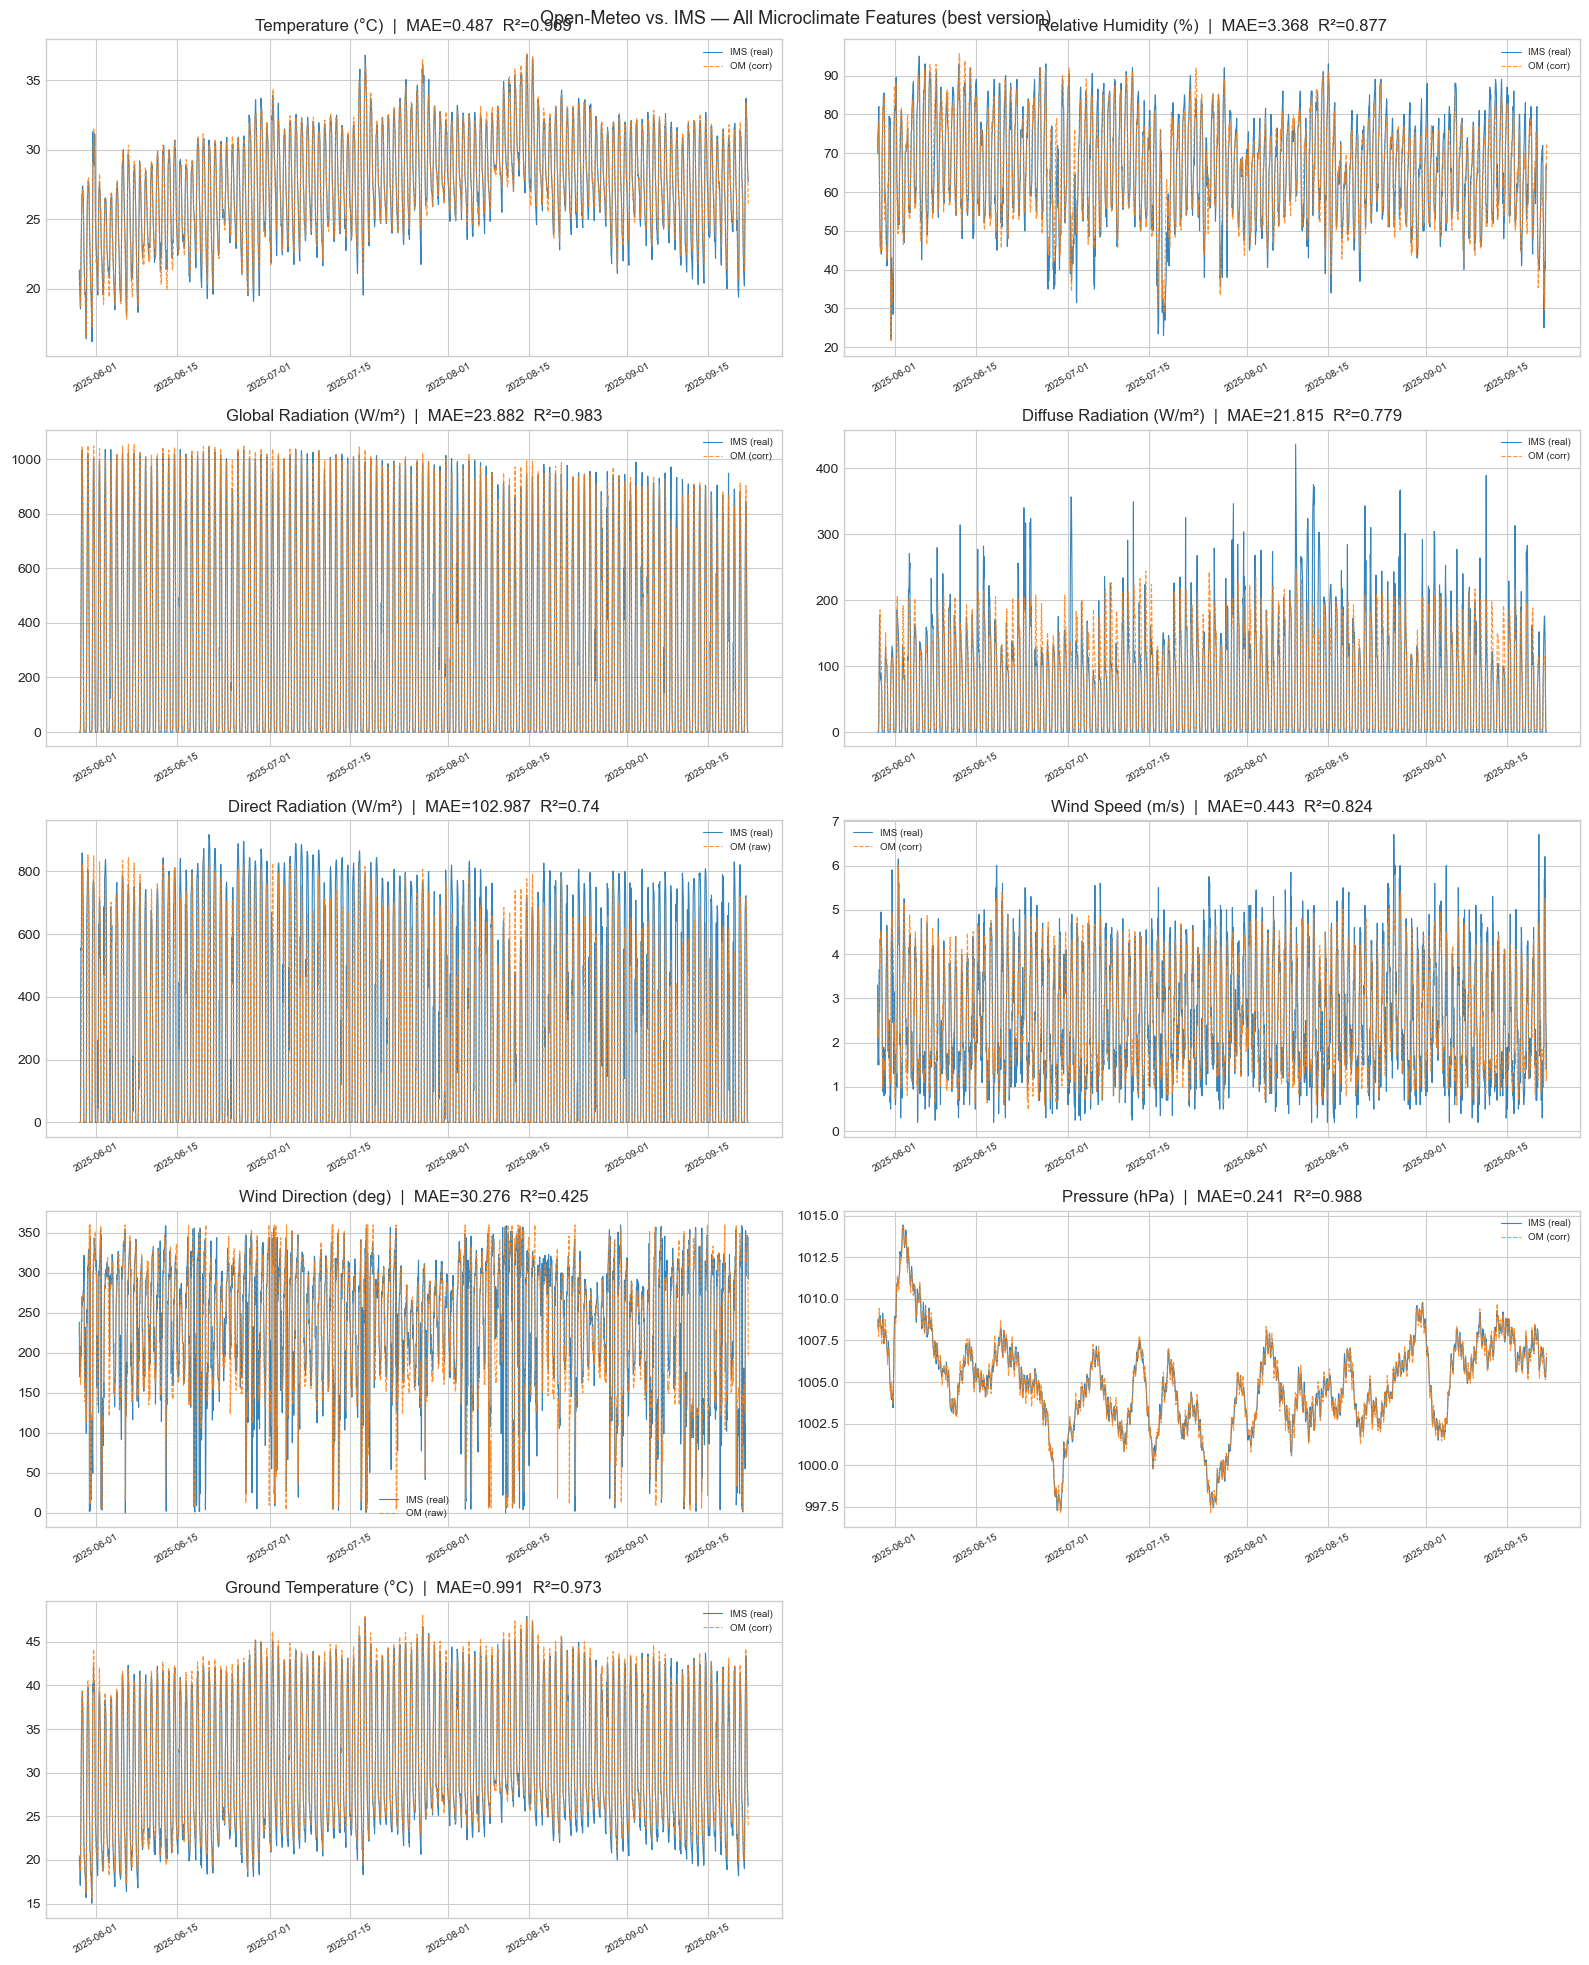

In [8]:
# Cell 8 — Time series plots
n = len(comparisons)
ncols, nrows = 2, (n + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for ax, (om_col, ims_col, label) in zip(axes, comparisons):
    use_col, _, corrected = final_cols[label]
    sub = merged[['timestamp', use_col, ims_col]].dropna().iloc[::4]
    row = corr_df[corr_df['Variable'] == label].iloc[0]
    r2_show  = row['R² corrected']  if corrected else row['R² raw']
    mae_show = row['MAE corrected'] if corrected else row['MAE raw']
    ax.plot(sub['timestamp'], sub[ims_col],  label='IMS (real)', linewidth=0.8, alpha=0.9)
    ax.plot(sub['timestamp'], sub[use_col],
            label=f'OM ({"corr" if corrected else "raw"})',
            linewidth=0.8, alpha=0.85, linestyle='--')
    ax.set_title(f'{label}  |  MAE={mae_show}  R²={r2_show}')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for ax in axes[n:]: ax.set_visible(False)
plt.suptitle('Open-Meteo vs. IMS — All Microclimate Features (best version)', fontsize=13)
plt.tight_layout()
plt.savefig('microclimate_features_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


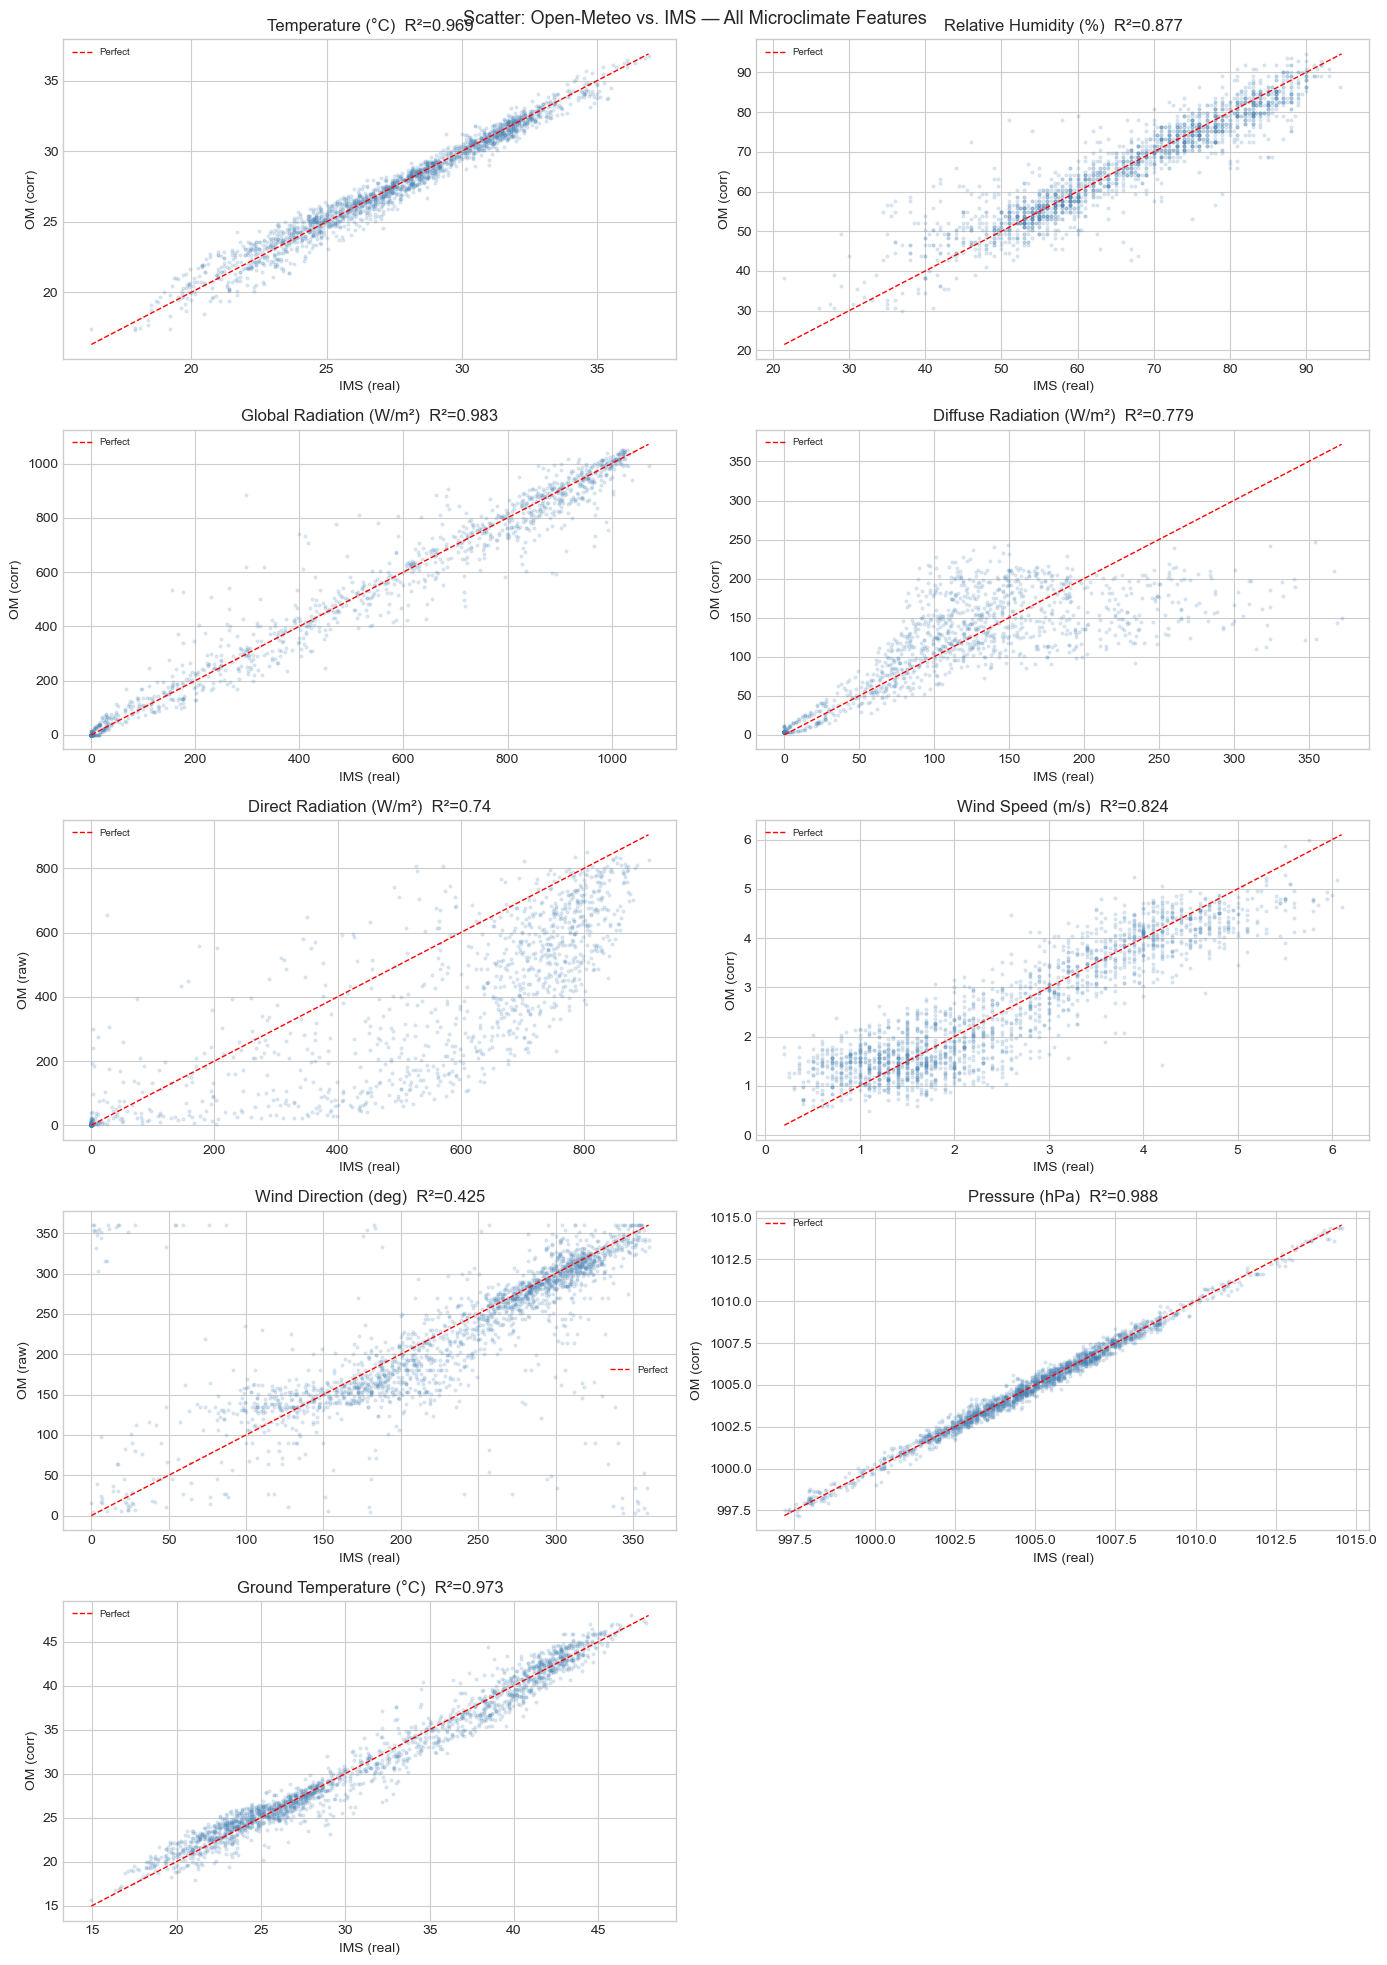

In [9]:
# Cell 9 — Scatter plots
n = len(comparisons)
ncols, nrows = 2, (n + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for ax, (om_col, ims_col, label) in zip(axes, comparisons):
    use_col, _, corrected = final_cols[label]
    sub = merged[[use_col, ims_col]].dropna().sample(min(2000, len(merged)), random_state=42)
    ax.scatter(sub[ims_col], sub[use_col], alpha=0.15, s=4, color='steelblue')
    mn = min(sub[ims_col].min(), sub[use_col].min())
    mx = max(sub[ims_col].max(), sub[use_col].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1, label='Perfect')
    row = corr_df[corr_df['Variable'] == label].iloc[0]
    r2_show = row['R² corrected'] if corrected else row['R² raw']
    ax.set_xlabel('IMS (real)')
    ax.set_ylabel(f'OM ({"corr" if corrected else "raw"})')
    ax.set_title(f'{label}  R²={r2_show}')
    ax.legend(fontsize=7)

for ax in axes[n:]: ax.set_visible(False)
plt.suptitle('Scatter: Open-Meteo vs. IMS — All Microclimate Features', fontsize=13)
plt.tight_layout()
plt.show()


In [10]:
# Cell 10 — Feature readiness summary + save correction coefficients
print('=' * 65)
print('MICROCLIMATE MODEL — Open-Meteo Feature Readiness Summary')
print('=' * 65)
print(f'{"Feature":<28} {"R² corr":>8}  Status')
print('-' * 65)
for row in corrected_results:
    r2 = row['R² corrected']
    status = ('✅ Ready' if r2 > 0.85 else
              '⚠️  Usable with caution' if r2 > 0.70 else
              '❌ Unreliable')
    print(f"{row['Variable']:<28} {r2:>8.3f}  {status}")
print('-' * 65)

print('\nDerived features (computed from raw — no API needed):')
for d in ['vpd_ext ← temp+rh', 'abs_humidity_ext ← temp+rh',
          'dew_point_ext ← temp+rh', 'temp_c_ext_med6 ← rolling(temp)',
          'global_rad_wm2_med6 ← rolling(global_rad)',
          'diffuse_rad_wm2_med6 ← rolling(diffuse_rad)',
          'rad_integral_1h ← rolling sum', 'rad_peak_intensity ← rolling max',
          'rad_slope_30m/1h ← diff', 'sunrise/sunset flags ← global_rad',
          'minutes_since_sunrise/sunset', 'hour_of_day', 'day_of_year']:
    print(f'  ✅ {d}')
print('=' * 65)

# Save coefficients CSV
coef_rows = []
for om_col, ims_col, label in comparisons:
    lr = lr_models[om_col]
    coef_rows.append({
        'om_variable': om_col, 'ims_variable': ims_col, 'label': label,
        'coef': round(lr.coef_[0], 6), 'intercept': round(lr.intercept_, 6)
    })
coef_df = pd.DataFrame(coef_rows)
coef_df.to_csv('microclimate_bias_correction_coefficients.csv', index=False)
print('\nSaved: microclimate_bias_correction_coefficients.csv')
display(coef_df)


MICROCLIMATE MODEL — Open-Meteo Feature Readiness Summary
Feature                       R² corr  Status
-----------------------------------------------------------------
Temperature (°C)                0.969  ✅ Ready
Relative Humidity (%)           0.877  ✅ Ready
Global Radiation (W/m²)         0.983  ✅ Ready
Diffuse Radiation (W/m²)        0.779  ⚠️  Usable with caution
Direct Radiation (W/m²)         0.825  ⚠️  Usable with caution
Wind Speed (m/s)                0.824  ⚠️  Usable with caution
Wind Direction (deg)            0.526  ❌ Unreliable
Pressure (hPa)                  0.988  ✅ Ready
Ground Temperature (°C)         0.973  ✅ Ready
-----------------------------------------------------------------

Derived features (computed from raw — no API needed):
  ✅ vpd_ext ← temp+rh
  ✅ abs_humidity_ext ← temp+rh
  ✅ dew_point_ext ← temp+rh
  ✅ temp_c_ext_med6 ← rolling(temp)
  ✅ global_rad_wm2_med6 ← rolling(global_rad)
  ✅ diffuse_rad_wm2_med6 ← rolling(diffuse_rad)
  ✅ rad_integral_1h ← 

,om_variable,ims_variable,label,coef,intercept
0,temp_om,temp,Temperature (°C),1.087231,-1.731937
1,rh_om,rh,Relative Humidity (%),0.926635,2.942798
2,global_rad_om,global_rad,Global Radiation (W/m²),1.056737,1.153412
3,diffuse_rad_om,diffuse_rad,Diffuse Radiation (W/m²),0.777966,3.786476
4,direct_rad_om,direct_rad,Direct Radiation (W/m²),1.139404,60.825897
5,wind_speed_om,wind_speed,Wind Speed (m/s),1.086135,0.486524
6,wind_dir_om,wind_dir,Wind Direction (deg),0.705244,74.896378
7,pressure_om,pressure,Pressure (hPa),0.993477,7.406128
8,soil_temp_om,temp_ground,Ground Temperature (°C),1.044372,-0.480259
